# Detecting Anomalous & Potentially Fraudulent Reviews in the Yelp Open Dataset
### Module 21 — Exploratory Data Analysis & Baseline Model

**Research question:** *Can machine-learning techniques identify potentially fraudulent or
anomalous reviews in the Yelp Open Dataset using behavioral, temporal, and linguistic patterns?*

Online reviews drive real consumer and business decisions. Because the Yelp Open Dataset has
**no reliable ground-truth labels for fake reviews**, this project frames the problem as
**unsupervised anomaly detection**: we engineer behavioral, temporal, and linguistic features and
let the model surface reviewers whose activity deviates sharply from normal patterns. The output
is a *ranked list of suspicious users* — leads for human investigation, not proof of fraud.

**This notebook (Module 21) covers:**
1. A memory-aware loading strategy for the multi-gigabyte raw JSON files
2. Data cleaning
3. Feature engineering — behavioral, temporal, and linguistic (NLP) signals
4. Exploratory data analysis with visualizations
5. A **baseline** unsupervised model (**Isolation Forest**) and a ranked suspicion list

The richer model comparison (Local Outlier Factor, One-Class SVM, tuning) is deferred to Module 24,
for which this Isolation Forest serves as the baseline.

## 1. Setup & Configuration

In [1]:
import os, glob, json, warnings, random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- Sampling configuration -------------------------------------------------
# The raw review file holds ~6.99M reviews (~5GB). To compute per-user temporal &
# behavioral features *correctly* we cannot take a random sample of reviews
# (that fragments each user's history). Instead we sample a set of USERS and then
# load *every* review they wrote, preserving complete per-user timelines.
#
# IMPORTANT: user.json's `review_count` is a user's *global* Yelp total, but the
# academic review file contains only a subset of reviews. So we define cohort
# eligibility by each user's *in-dataset* review count (counted from the review
# file itself) to guarantee genuinely usable per-user histories.
N_USERS      = 12000   # number of users to sample
MIN_REVIEWS  = 10      # min in-dataset reviews -> measurable burstiness / variance
MAX_REVIEWS  = 300     # cap extreme power-users to bound memory & runtime

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 2.4.6


In [2]:
# Locate the extracted Yelp JSON files (search recursively under ./data)
def find_file(pattern):
    hits = glob.glob(f"data/**/{pattern}", recursive=True)
    if not hits:
        raise FileNotFoundError(f"Could not find {pattern} under ./data — "
                                "extract Yelp-JSON.zip first.")
    return hits[0]

REVIEW_PATH   = find_file("yelp_academic_dataset_review.json")
USER_PATH     = find_file("yelp_academic_dataset_user.json")
BUSINESS_PATH = find_file("yelp_academic_dataset_business.json")

for p in (REVIEW_PATH, USER_PATH, BUSINESS_PATH):
    print(f"{os.path.getsize(p)/1e9:5.2f} GB  {p}")

 5.34 GB  data/yelp_academic_dataset_review.json
 3.36 GB  data/yelp_academic_dataset_user.json
 0.12 GB  data/yelp_academic_dataset_business.json


## 2. Data Loading

The files are newline-delimited JSON (one object per line). We stream them line-by-line so we never
hold a whole multi-GB file in memory.

- **Businesses** (~150k rows, small) — loaded fully. Yelp pre-computes each business's `stars`
  (average rating), which we use for the *rating-deviation* feature.
- **Reviews — pass 1** (count): stream the whole review file once to count each user's
  *in-dataset* reviews, then randomly sample `N_USERS` users whose count is in
  `[MIN_REVIEWS, MAX_REVIEWS]`.
- **Users**: stream `user.json` once, keeping account-level features only for the sampled users.
- **Reviews — pass 2** (collect): stream the review file again, keeping every review written by a
  sampled user — yielding complete per-user histories.

In [3]:
# ---- 2a. Businesses: keep id -> average stars (and a little metadata) ------
biz_records = []
with open(BUSINESS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        d = json.loads(line)
        biz_records.append((d["business_id"], d.get("stars"),
                            d.get("review_count"), d.get("city"),
                            d.get("state"), d.get("categories")))
business_df = pd.DataFrame(biz_records, columns=[
    "business_id", "biz_avg_stars", "biz_review_count", "city", "state", "categories"])
biz_avg = business_df.set_index("business_id")["biz_avg_stars"]
print(f"Loaded {len(business_df):,} businesses")
business_df.head()

Loaded 150,346 businesses


,business_id,biz_avg_stars,biz_review_count,city,state,categories
0,Pns2l4eNsfO8kk83dixA6A,5.0,7,Santa Barbara,CA,"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,3.0,15,Affton,MO,"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,3.5,22,Tucson,AZ,"Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,4.0,80,Philadelphia,PA,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,4.5,13,Green Lane,PA,"Brewpubs, Breweries, Food"


In [4]:
# ---- 2b. Pass 1: count each user's IN-DATASET reviews, then sample users ----
from collections import Counter

user_counts = Counter()
with open(REVIEW_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        user_counts[json.loads(line)["user_id"]] += 1
        if i % 2_000_000 == 0:
            print(f"  counted {i:,} reviews...")

total_reviews = sum(user_counts.values())
print(f"Review file: {total_reviews:,} reviews across {len(user_counts):,} distinct users")

eligible = [u for u, c in user_counts.items() if MIN_REVIEWS <= c <= MAX_REVIEWS]
rng = random.Random(RANDOM_SEED)
sampled_user_ids = set(rng.sample(eligible, min(N_USERS, len(eligible))))
print(f"Users with {MIN_REVIEWS}-{MAX_REVIEWS} in-dataset reviews: {len(eligible):,}"
      f"  ->  sampled {len(sampled_user_ids):,}")

  counted 2,000,000 reviews...


  counted 4,000,000 reviews...


  counted 6,000,000 reviews...


Review file: 6,990,280 reviews across 1,987,929 distinct users
Users with 10-300 in-dataset reviews: 116,874  ->  sampled 12,000


In [5]:
# ---- 2c. Users: stream user.json, keep features for the sampled users only --
USER_FIELDS = ["user_id", "review_count", "average_stars", "yelping_since",
               "useful", "funny", "cool", "fans", "elite", "friends",
               "compliment_hot", "compliment_more", "compliment_writer"]
urows = []
with open(USER_PATH, "r", encoding="utf-8") as f:
    for line in f:
        d = json.loads(line)
        if d["user_id"] in sampled_user_ids:
            urows.append({k: d.get(k) for k in USER_FIELDS})
users_df = pd.DataFrame(urows)
print(f"Loaded account features for {len(users_df):,} sampled users")
users_df.head()

Loaded account features for 12,000 sampled users


,user_id,review_count,average_stars,yelping_since,useful,funny,cool,fans,elite,friends,compliment_hot,compliment_more,compliment_writer
0,AUi8MPWJ0mLkMfwbui27lg,109,3.40,2010-01-07 18:32:04,154,20,23,4,,"gy5fWeSv3Gamuq9Ox4MV4g, lMr3LWU6kPFLTmCpDkACxg...",0,0,0
1,1L3O2CUTk27SnmqyPBWQdQ,38,3.98,2010-09-09 16:41:46,62,6,9,0,,"NU90Jxo_0Ep-kXQGorBlVg, vJMUItkTvppKlJYW0DCu_A...",0,0,5
2,rppTTi-kfF8-qyiArNemag,460,3.33,2006-01-24 14:33:32,700,149,425,49,"2010,2012,2013,2014,2015,2016,2017,2018","HzoQKKHDq9BI37dyJAAtGA, Inh7WS8hpmiUmNDhtLK-ZQ...",25,11,20
3,VHdY6oG2JPVNjihWhOooAQ,2101,4.22,2005-07-21 01:16:04,47831,28830,44899,2627,"2006,2007,2008,2009,2010,2011,2012,2013,2014,2...","YTqvt6PKmQS-Ygk_JeyXZQ, NhAJ4Fv4xDkWJYo85Y3yOQ...",6104,404,2313
4,hSMVQ7MSh6B0OgPxFQFO8g,920,3.95,2009-01-25 06:23:45,2377,729,1415,88,"2009,2010,2011,2012,2013,2014","FZ-2nh3-bcE0zhxECyyXEQ, dJvzA41GNxwIkZAM0a9u-w...",214,25,86


In [6]:
# ---- 2d. Pass 2: collect every review written by the sampled users ----------
REVIEW_FIELDS = ["review_id", "user_id", "business_id", "stars",
                 "date", "text", "useful", "funny", "cool"]

def load_reviews_for_users(path, user_ids):
    rows, scanned = [], 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            scanned += 1
            d = json.loads(line)
            if d["user_id"] in user_ids:
                rows.append({k: d.get(k) for k in REVIEW_FIELDS})
            if scanned % 2_000_000 == 0:
                print(f"  scanned {scanned:,} reviews, kept {len(rows):,}")
    return pd.DataFrame(rows)

reviews_df = load_reviews_for_users(REVIEW_PATH, sampled_user_ids)
print(f"\nKept {len(reviews_df):,} reviews from {reviews_df['user_id'].nunique():,} users "
      f"(mean {len(reviews_df)/reviews_df['user_id'].nunique():.1f} reviews/user)")
reviews_df.head()

  scanned 2,000,000 reviews, kept 90,333


  scanned 4,000,000 reviews, kept 180,718


  scanned 6,000,000 reviews, kept 270,251



Kept 313,752 reviews from 12,000 users (mean 26.1 reviews/user)


,review_id,user_id,business_id,stars,date,text,useful,funny,cool
0,lUUhg8ltDsUZ9h0xnwY4Dg,RreNy--tOmXMl1en0wiBOg,cPepkJeRMtHapc_b2Oe_dw,4.0,2018-07-17 03:30:07,I was really between 3 and 4 stars for this on...,1,0,1
1,RB8UpF_kT2xoOC51OzXEeA,EZjT2qJN0mOXypMAqZdSrQ,A2q7d-CBM2-81tVkmS4JMw,2.0,2017-07-08 18:58:42,"Straight to the point, it's cheap, it tastes a...",1,1,0
2,Ki90-hauSIfW_7sBuBBqfA,Z2cOL3n9V8NoguJ-uU_Nvw,j8JOZvfeHEfUWq3gEz6ABQ,2.0,2014-06-11 14:55:14,NEVER AGAIN. This is a so called restaurant th...,2,3,0
3,A4n4YaE-owOVgTQcrVqHUw,S7bjj-L07JuRr-tpX1UZLw,I6L0Zxi5Ww0zEWSAVgngeQ,4.0,2018-07-07 20:50:12,The cafe was extremely cute. We came at 8am an...,0,0,0
4,fGYcFOHfQL4stYPdD3J47g,CgyCtH9CbLO7J_uO3cL7OA,PzhPMkaNYiKDTHoTG0r8rw,4.0,2016-09-18 22:43:18,After 3 weeks of working in the area I finally...,0,0,0


## 3. Data Cleaning

In [7]:
print("Missing values per column:")
print(reviews_df.isna().sum())

# Parse timestamps, drop rows missing critical fields, remove exact-duplicate reviews
reviews_df["date"] = pd.to_datetime(reviews_df["date"], errors="coerce")
before = len(reviews_df)
reviews_df = reviews_df.dropna(subset=["review_id", "user_id", "business_id",
                                       "stars", "date", "text"])
reviews_df = reviews_df.drop_duplicates(subset="review_id")
reviews_df["text"] = reviews_df["text"].astype(str)
reviews_df["stars"] = reviews_df["stars"].astype(float)

# Parse user account-creation date & elite-year count
users_df["yelping_since"] = pd.to_datetime(users_df["yelping_since"], errors="coerce")
users_df["elite_count"] = users_df["elite"].fillna("").apply(
    lambda s: 0 if not str(s).strip() else len([y for y in str(s).split(",") if y.strip()]))
users_df["friend_count"] = users_df["friends"].fillna("").apply(
    lambda s: 0 if not str(s).strip() or s == "None" else len(str(s).split(",")))

print(f"\nDropped {before - len(reviews_df):,} rows; {len(reviews_df):,} clean reviews remain")

Missing values per column:
review_id      0
user_id        0
business_id    0
stars          0
date           0
text           0
useful         0
funny          0
cool           0
dtype: int64



Dropped 0 rows; 313,752 clean reviews remain


## 4. Exploratory Data Analysis — Raw Signals

Before engineering features we look at the basic shape of the data: how ratings, review length,
posting time, and per-user activity are distributed. These distributions motivate the features and
help us spot the patterns anomaly detection should key on.

In [8]:
print("Reviews:", reviews_df.shape, "| Users:", users_df.shape)
print(f"Date range: {reviews_df['date'].min().date()}  ->  {reviews_df['date'].max().date()}")
reviews_df[["stars", "useful", "funny", "cool"]].describe()

Reviews: (313752, 9) | Users: (12000, 15)
Date range: 2005-03-08  ->  2022-01-19


,stars,useful,funny,cool
count,313752.000000,313752.000000,313752.000000,313752.000000
mean,3.820180,1.408950,0.401033,0.655986
std,1.317133,3.061513,1.632370,2.309300
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000
50%,4.000000,1.000000,0.000000,0.000000
75%,5.000000,2.000000,0.000000,1.000000
max,5.000000,358.000000,307.000000,358.000000


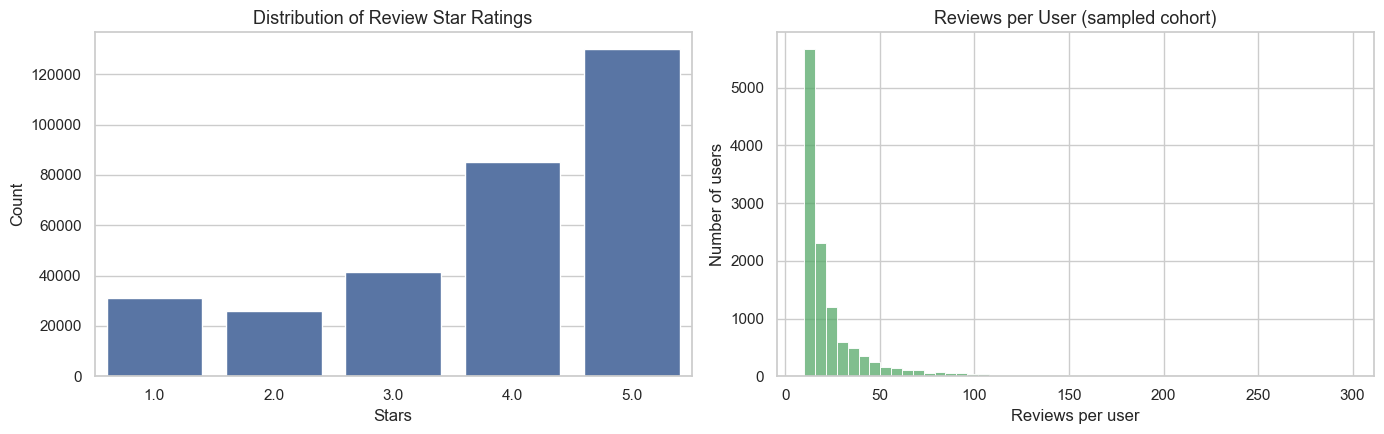

count    12000.000000
mean        26.146000
std         30.405288
min         10.000000
25%         12.000000
50%         16.000000
75%         26.000000
max        297.000000
dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
# Star-rating distribution
sns.countplot(x="stars", data=reviews_df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Review Star Ratings")
axes[0].set_xlabel("Stars"); axes[0].set_ylabel("Count")
# Reviews per user
rpu = reviews_df.groupby("user_id").size()
sns.histplot(rpu, bins=50, ax=axes[1], color="#55A868")
axes[1].set_title("Reviews per User (sampled cohort)")
axes[1].set_xlabel("Reviews per user"); axes[1].set_ylabel("Number of users")
plt.tight_layout(); plt.show()
print(rpu.describe())

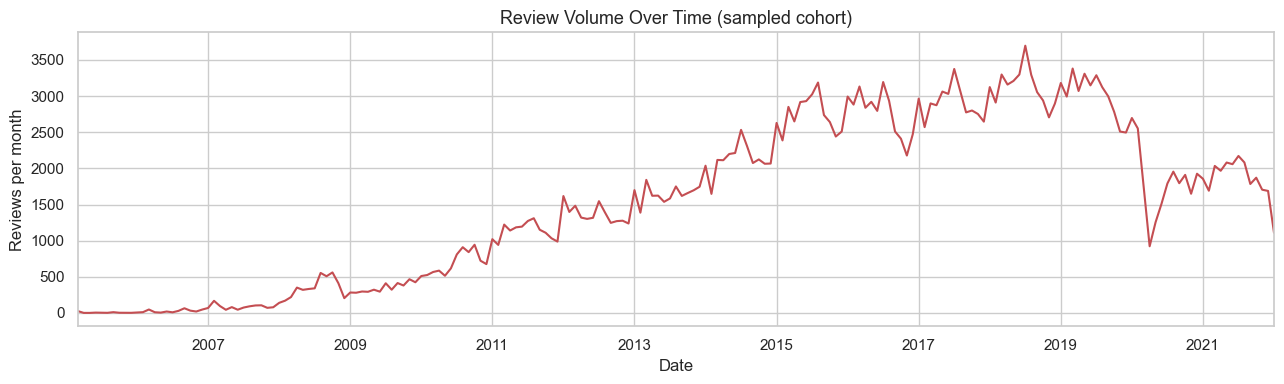

In [10]:
# Temporal trend: review volume over time
monthly = reviews_df.set_index("date").resample("ME").size()
fig, ax = plt.subplots(figsize=(13, 4))
monthly.plot(ax=ax, color="#C44E52")
ax.set_title("Review Volume Over Time (sampled cohort)")
ax.set_xlabel("Date"); ax.set_ylabel("Reviews per month")
plt.tight_layout(); plt.show()

## 5. Feature Engineering

We build three families of features motivated by the fraud-detection literature:

| Family | Features | Intuition |
|--------|----------|-----------|
| **Linguistic (NLP)** | review length (words/chars), VADER sentiment, exclamation & ALL-CAPS ratio | fake reviews are often short or extreme, with exaggerated sentiment & punctuation |
| **Rating** | deviation from the business's average rating, user rating variance | shills push ratings away from consensus or rate everything identically |
| **Temporal / behavioral** | inter-review gap, burstiness, max reviews-per-day, account age, votes-per-review | bots/paid reviewers post in bursts and earn few community votes |

In [11]:
# ---- 5a. Per-review linguistic features ------------------------------------
import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

txt = reviews_df["text"]
reviews_df["char_len"]  = txt.str.len()
reviews_df["word_len"]  = txt.str.split().apply(len)
reviews_df["exclaim_ratio"] = txt.str.count("!") / reviews_df["char_len"].clip(lower=1)
reviews_df["caps_ratio"]    = txt.apply(
    lambda s: sum(1 for c in s if c.isupper()) / max(len(s), 1))

print("Scoring sentiment with VADER (this is the slow step)...")
reviews_df["sentiment"] = txt.apply(lambda s: sia.polarity_scores(s)["compound"])
print("done.")
reviews_df[["char_len", "word_len", "exclaim_ratio", "caps_ratio", "sentiment"]].describe()

Scoring sentiment with VADER (this is the slow step)...


done.


,char_len,word_len,exclaim_ratio,caps_ratio,sentiment
count,313752.000000,313752.000000,313752.000000,313752.000000,313752.000000
mean,614.419121,113.380594,0.003062,0.027587,0.693922
std,532.052165,98.533447,0.006355,0.015984,0.512070
min,1.000000,1.000000,0.000000,0.000000,-0.998800
25%,263.000000,48.000000,0.000000,0.018970,0.730300
50%,460.000000,85.000000,0.000000,0.024352,0.928300
75%,789.000000,146.000000,0.003788,0.031873,0.974700
max,5000.000000,1028.000000,0.627119,1.000000,0.999900


In [12]:
# ---- 5b. Rating deviation from the business average ------------------------
reviews_df["biz_avg_stars"] = reviews_df["business_id"].map(biz_avg)
reviews_df["rating_deviation"] = reviews_df["stars"] - reviews_df["biz_avg_stars"]
reviews_df[["stars", "biz_avg_stars", "rating_deviation"]].describe()

,stars,biz_avg_stars,rating_deviation
count,313752.000000,313752.000000,313752.000000
mean,3.820180,3.773166,0.047013
std,1.317133,0.696754,1.185922
min,1.000000,1.000000,-4.000000
25%,3.000000,3.500000,-0.500000
50%,4.000000,4.000000,0.500000
75%,5.000000,4.500000,1.000000
max,5.000000,5.000000,4.000000


In [13]:
# ---- 5c. Temporal / behavioral features (per user) -------------------------
reviews_df = reviews_df.sort_values(["user_id", "date"])
# gap (days) between a user's consecutive reviews
reviews_df["gap_days"] = (reviews_df.groupby("user_id")["date"]
                          .diff().dt.total_seconds() / 86400)
reviews_df["review_day"] = reviews_df["date"].dt.normalize()

# Burstiness coefficient B = (sigma - mu) / (sigma + mu) of inter-review gaps.
# B -> +1 very bursty, 0 random (Poisson), -1 perfectly regular.
def burstiness(gaps):
    g = gaps.dropna()
    if len(g) < 2:
        return np.nan
    mu, sd = g.mean(), g.std()
    return (sd - mu) / (sd + mu) if (sd + mu) > 0 else np.nan

g = reviews_df.groupby("user_id")
feat = pd.DataFrame({
    "n_reviews"      : g.size(),
    "mean_gap_days"  : g["gap_days"].mean(),
    "min_gap_days"   : g["gap_days"].min(),
    "burstiness"     : g["gap_days"].apply(burstiness),
    "max_reviews_day": g["review_day"].apply(lambda s: s.value_counts().max()),
    "rating_std"     : g["stars"].std(),
    "mean_rating_dev": g["rating_deviation"].mean(),
    "abs_rating_dev" : g["rating_deviation"].apply(lambda s: s.abs().mean()),
    "mean_sentiment" : g["sentiment"].mean(),
    "std_sentiment"  : g["sentiment"].std(),
    "mean_word_len"  : g["word_len"].mean(),
    "mean_exclaim"   : g["exclaim_ratio"].mean(),
    "mean_caps"      : g["caps_ratio"].mean(),
})
feat.head()

,n_reviews,mean_gap_days,min_gap_days,burstiness,max_reviews_day,rating_std,mean_rating_dev,abs_rating_dev,mean_sentiment,std_sentiment,mean_word_len,mean_exclaim,mean_caps
user_id,,,,,,,,,,,,,
--WLSCJPoCNQmTmG2yPAcQ,14,214.929428,0.014479,-0.038500,2,1.392681,-1.250000,1.321429,0.279221,0.646837,119.357143,0.000035,0.022076
--ccVMj2PN6Z9qtdOdlung,14,154.039152,0.213924,0.423653,2,1.222500,-0.142857,0.500000,0.553286,0.713662,275.285714,0.000268,0.023385
--pMssoWlOqX0pLiPMiZZw,12,92.845816,0.004676,0.120357,2,1.164500,0.291667,0.875000,0.704358,0.578878,154.583333,0.003279,0.032700
--u09WAjW741FdfkJXxNmg,95,29.115918,0.002581,0.120363,2,1.084865,-0.321053,0.731579,0.784239,0.516256,155.136842,0.006587,0.020107
-00kdEIhCt-ODaV4BS-EAg,24,122.711814,0.004375,0.145601,3,0.978019,-0.250000,0.708333,0.561558,0.504830,100.708333,0.000000,0.021927


In [14]:
# ---- 5d. Text self-similarity per user (template / copy-paste detector) ----
# Average pairwise cosine similarity of a user's review TF-IDF vectors.
# High values flag users who post near-duplicate text across reviews.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def avg_self_similarity(texts):
    texts = [t for t in texts if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return 0.0
    try:
        X = TfidfVectorizer(max_features=400, stop_words="english").fit_transform(texts)
    except ValueError:
        return 0.0
    S = cosine_similarity(X)
    n = S.shape[0]
    return (S.sum() - n) / (n * (n - 1))   # mean of off-diagonal entries

print("Computing per-user text self-similarity...")
self_sim = reviews_df.groupby("user_id")["text"].apply(lambda s: avg_self_similarity(list(s)))
feat["text_self_sim"] = self_sim
print("done.")
feat[["text_self_sim"]].describe()

Computing per-user text self-similarity...


done.


,text_self_sim
count,12000.000000
mean,0.056051
std,0.022108
min,0.009123
25%,0.041992
50%,0.053152
75%,0.066619
max,1.000000


In [15]:
# ---- 5e. Merge in user-account features & assemble the user feature matrix --
udf = users_df.set_index("user_id")
acct_age_days = (reviews_df["date"].max() - udf["yelping_since"]).dt.days
feat = feat.join(pd.DataFrame({
    "acct_age_days"   : acct_age_days,
    "fans"            : udf["fans"],
    "elite_count"     : udf["elite_count"],
    "friend_count"    : udf["friend_count"],
    "useful_votes"    : udf["useful"],
}))
feat["useful_per_review"] = feat["useful_votes"] / feat["n_reviews"].clip(lower=1)

feat = feat.replace([np.inf, -np.inf], np.nan)
print("User feature matrix:", feat.shape)
feat.describe().T[["mean", "std", "min", "50%", "max"]]

User feature matrix: (12000, 20)


,mean,std,min,50%,max
n_reviews,26.146000,30.405288,10.000000,16.000000,297.000000
mean_gap_days,101.719967,80.268169,0.000224,84.009402,578.565567
min_gap_days,0.793362,4.524566,0.000000,0.002060,123.820903
burstiness,0.269031,0.181066,-0.601193,0.271371,0.847574
max_reviews_day,4.140833,3.399357,1.000000,3.000000,57.000000
rating_std,1.187012,0.419240,0.000000,1.206045,2.108185
mean_rating_dev,0.032979,0.554730,-2.785714,0.080000,2.071429
abs_rating_dev,0.975076,0.317229,0.100000,0.928571,2.785714
mean_sentiment,0.665607,0.237548,-0.694453,0.722495,0.997342
std_sentiment,0.445467,0.217434,0.000000,0.468398,0.966156


## 6. EDA on Engineered Features

Now we examine the engineered signals and how they relate to one another. Strong correlations and
heavy-tailed distributions are exactly where anomaly detection finds traction.

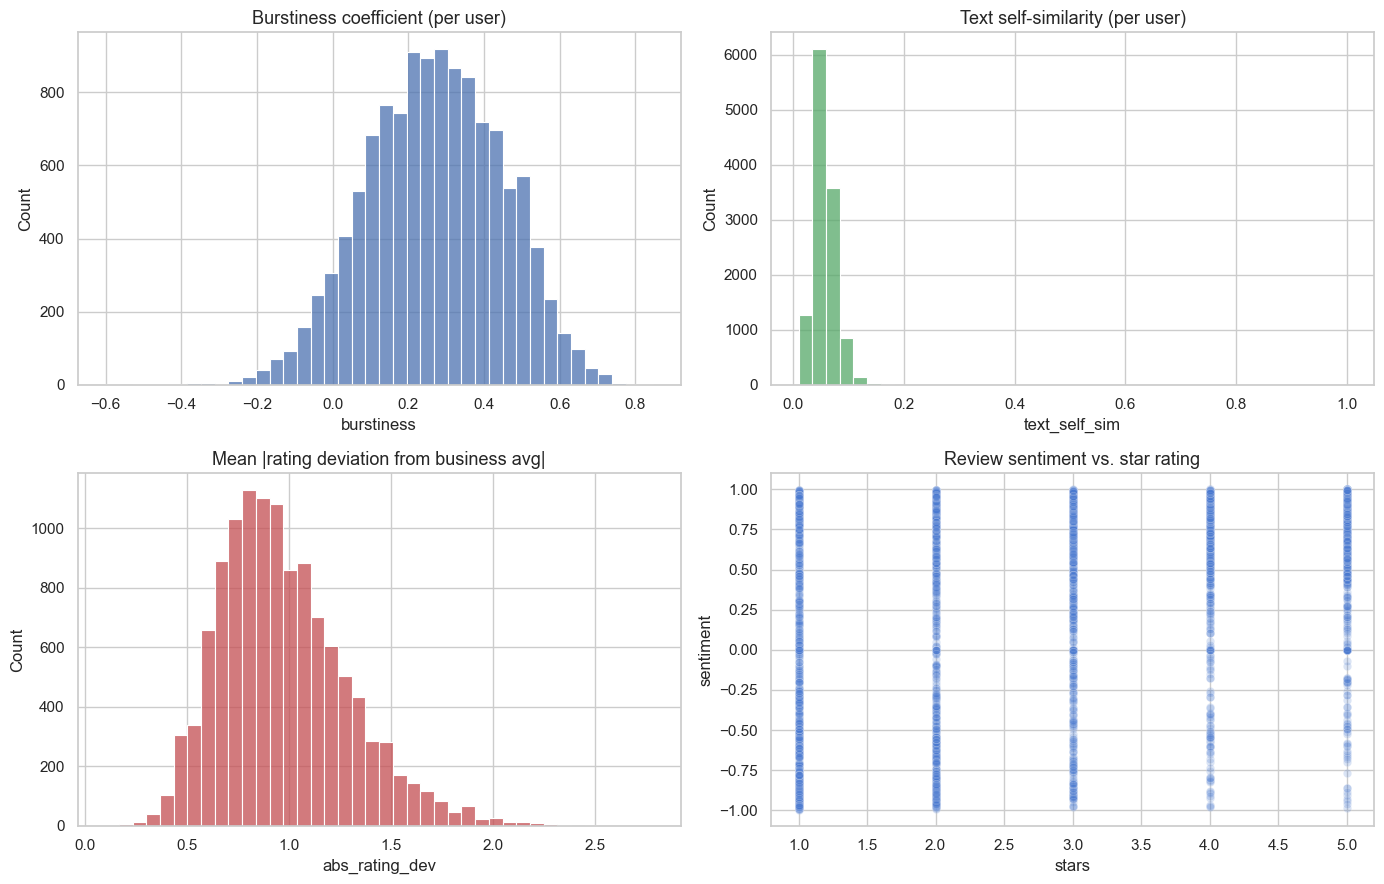

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(feat["burstiness"].dropna(), bins=40, ax=axes[0,0], color="#4C72B0")
axes[0,0].set_title("Burstiness coefficient (per user)")
sns.histplot(feat["text_self_sim"].dropna(), bins=40, ax=axes[0,1], color="#55A868")
axes[0,1].set_title("Text self-similarity (per user)")
sns.histplot(feat["abs_rating_dev"].dropna(), bins=40, ax=axes[1,0], color="#C44E52")
axes[1,0].set_title("Mean |rating deviation from business avg|")
sns.scatterplot(x="stars", y="sentiment", data=reviews_df.sample(min(8000, len(reviews_df)),
                random_state=RANDOM_SEED), alpha=0.2, ax=axes[1,1])
axes[1,1].set_title("Review sentiment vs. star rating")
plt.tight_layout(); plt.show()

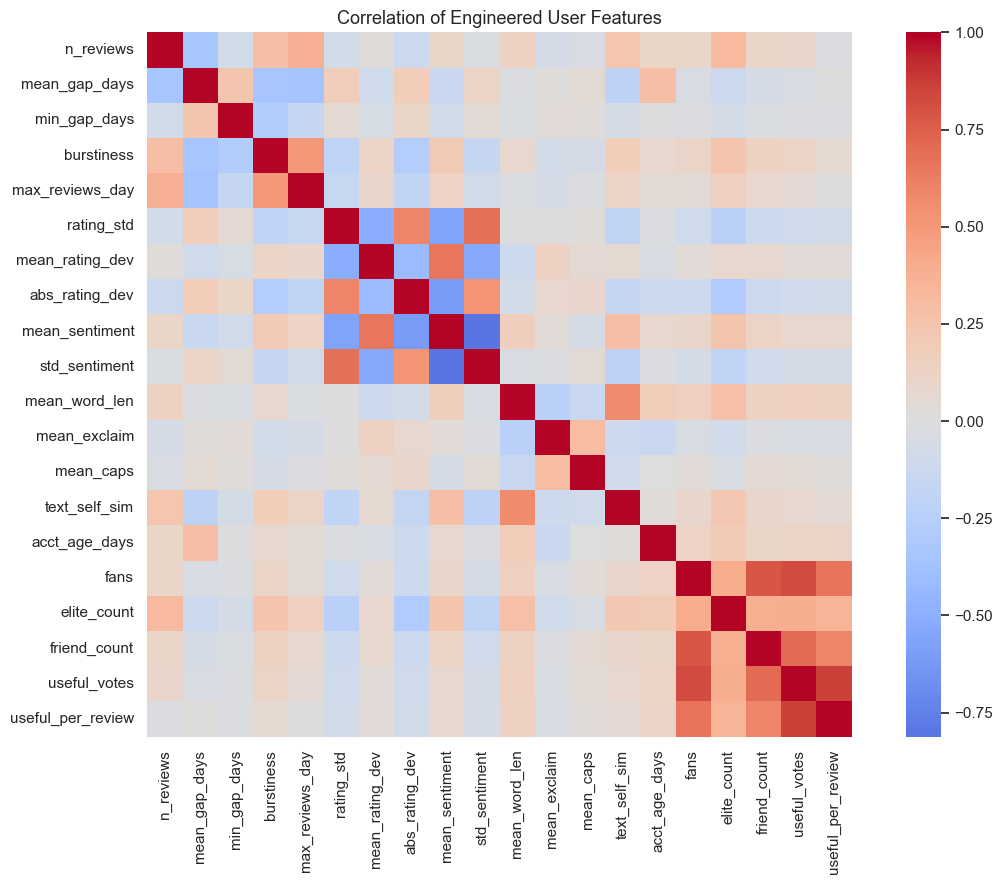

In [17]:
# Correlation heatmap of the engineered user features
corr = feat.corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation of Engineered User Features")
plt.tight_layout(); plt.show()

## 7. Baseline Model — Isolation Forest

Isolation Forest is a natural unsupervised baseline: it isolates observations with random splits and
assigns higher anomaly scores to points that are *easy to isolate* (i.e., far from the dense normal
region). It scales well, needs no labels, and handles the mixed, heavy-tailed features above.

We impute missing values (median), standardize, and fit with a 5% contamination prior — i.e., we ask
the model to flag the ~5% most anomalous reviewers as candidates for review.

In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

MODEL_FEATURES = [
    "n_reviews", "mean_gap_days", "min_gap_days", "burstiness", "max_reviews_day",
    "rating_std", "abs_rating_dev", "mean_sentiment", "std_sentiment",
    "mean_word_len", "mean_exclaim", "mean_caps", "text_self_sim",
    "acct_age_days", "fans", "elite_count", "friend_count", "useful_per_review",
]
X = feat[MODEL_FEATURES].copy()
X_imp = SimpleImputer(strategy="median").fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imp)

iso = IsolationForest(n_estimators=300, contamination=0.05,
                      random_state=RANDOM_SEED, n_jobs=-1)
iso.fit(X_scaled)

feat["anomaly_score"] = -iso.score_samples(X_scaled)   # higher = more anomalous
feat["is_anomaly"]    = iso.predict(X_scaled) == -1
print(f"Flagged {feat['is_anomaly'].sum():,} of {len(feat):,} users "
      f"({100*feat['is_anomaly'].mean():.1f}%) as anomalous")

Flagged 600 of 12,000 users (5.0%) as anomalous


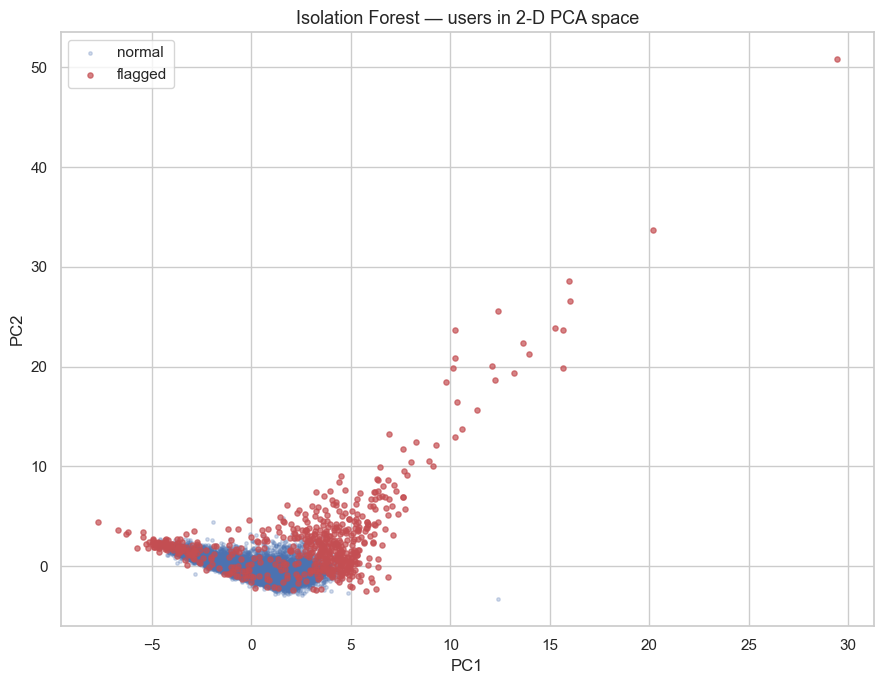

In [19]:
# 2-D PCA projection coloured by anomaly flag
from sklearn.decomposition import PCA
pc = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X_scaled)
plt.figure(figsize=(9, 7))
plt.scatter(pc[~feat["is_anomaly"].values, 0], pc[~feat["is_anomaly"].values, 1],
            s=6, alpha=0.25, label="normal", color="#4C72B0")
plt.scatter(pc[feat["is_anomaly"].values, 0], pc[feat["is_anomaly"].values, 1],
            s=14, alpha=0.7, label="flagged", color="#C44E52")
plt.title("Isolation Forest — users in 2-D PCA space")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.tight_layout(); plt.show()

In [20]:
# Compare flagged vs. normal users across key features
compare = (feat.groupby("is_anomaly")[
    ["n_reviews", "burstiness", "min_gap_days", "max_reviews_day",
     "abs_rating_dev", "rating_std", "text_self_sim", "mean_caps",
     "useful_per_review", "acct_age_days"]].median().T)
compare.columns = ["normal (median)", "flagged (median)"]
compare

,normal (median),flagged (median)
n_reviews,16.000000,16.000000
burstiness,0.268785,0.351456
min_gap_days,0.002025,0.003368
max_reviews_day,3.000000,3.000000
abs_rating_dev,0.933333,0.800547
rating_std,1.220793,0.938988
text_self_sim,0.052680,0.067531
mean_caps,0.026651,0.027425
useful_per_review,1.500000,21.875000
acct_age_days,3185.500000,3897.000000


In [21]:
# Ranked list of the most suspicious users
ranked = feat.sort_values("anomaly_score", ascending=False)
top = ranked.head(15)[[
    "anomaly_score", "n_reviews", "burstiness", "min_gap_days", "max_reviews_day",
    "abs_rating_dev", "rating_std", "text_self_sim", "mean_caps", "useful_per_review"]]
top.round(3)

,anomaly_score,n_reviews,burstiness,min_gap_days,max_reviews_day,abs_rating_dev,rating_std,text_self_sim,mean_caps,useful_per_review
user_id,,,,,,,,,,
VHdY6oG2JPVNjihWhOooAQ,0.683,19,0.533,0.749,2,0.553,0.582,0.074,0.026,2517.421
mvK1pv-x0Z5rP4Hz9cWBWw,0.673,50,0.477,0.003,8,0.570,0.752,0.064,0.116,623.420
LMoK9BUP6Tgfc0AeDVbZHQ,0.666,11,0.020,0.926,1,0.318,0.632,0.089,0.024,802.273
B7ecAeAIrXg7sgmabS38pg,0.644,28,0.433,0.003,8,0.821,1.122,0.101,0.026,893.179
svFLKTgoPjO7nQu5bFxsdQ,0.644,15,0.051,1.266,1,0.867,1.163,0.105,0.032,1572.400
-FZBTkAZEXoP7CYvRV2ZwQ,0.643,21,0.614,0.001,13,1.595,0.717,0.086,0.028,1636.952
f-iREBx-5CznQjIMWmoOkw,0.641,25,0.444,0.000,4,0.580,0.726,0.076,0.046,1620.200
C1AebaLdwqjOpZRaHKWKAw,0.640,11,0.038,6.457,1,0.818,0.982,0.123,0.017,48.818
rcU7ysY41qGppbw4pQgjqg,0.637,40,0.418,0.570,2,0.688,0.921,0.059,0.025,399.950


In [22]:
# Inspect the single most anomalous user's reviews to sanity-check the signal
top_user = ranked.index[0]
print("Most anomalous user_id:", top_user)
print(feat.loc[top_user, ["n_reviews", "burstiness", "min_gap_days",
      "max_reviews_day", "text_self_sim", "abs_rating_dev"]].round(3).to_dict())
cols = ["date", "business_id", "stars", "biz_avg_stars", "word_len", "sentiment"]
reviews_df[reviews_df["user_id"] == top_user].sort_values("date")[cols].head(15)

Most anomalous user_id: VHdY6oG2JPVNjihWhOooAQ
{'n_reviews': 19.0, 'burstiness': 0.533, 'min_gap_days': 0.749, 'max_reviews_day': 2.0, 'text_self_sim': 0.074, 'abs_rating_dev': 0.553}


,date,business_id,stars,biz_avg_stars,word_len,sentiment
141037,2010-05-04 23:54:40,QyuF5F7cj02WXIF2nOgzBg,4.0,3.5,386,0.9918
7654,2011-06-16 22:19:05,BrYoQyygyIb-FsVJ0AMpLg,5.0,4.5,316,0.9977
75565,2011-06-17 23:46:59,3iSRhLUZfZSlLaQw-BzloQ,4.0,3.5,350,0.9776
135749,2011-06-18 22:44:38,tELoGj2QJYYFQ1jo_XXbpA,4.0,4.5,161,0.8714
232163,2011-06-21 20:32:24,7u3LzhyxgPMo__24R4dmAQ,4.0,3.5,170,0.9965
83339,2011-06-24 20:15:42,6xzI0yNPXI5POpjoN7po0Q,3.0,3.5,226,0.9881
69327,2011-07-07 23:18:22,ArZHhE6Pmo49bJsB_a4n4A,4.0,3.0,395,0.9958
68029,2011-07-09 22:02:48,_XlYymFKwww0bGIgwvNbcA,4.0,4.0,265,0.9889
179667,2019-05-01 20:36:24,swVdc9piXvG0AXwL-F0GfQ,5.0,4.5,207,0.9802
111985,2019-05-02 17:14:12,nYzCXMzSk8pjMnYVI6z3RA,5.0,4.0,151,0.9918


In [23]:
# Persist the ranked suspicion list for downstream work (Module 24)
out = ranked.reset_index().rename(columns={"index": "user_id"})
out.to_csv("data/ranked_suspicious_users.csv", index=False)
print(f"Saved ranked list of {len(out):,} users -> data/ranked_suspicious_users.csv")
out.head()

Saved ranked list of 12,000 users -> data/ranked_suspicious_users.csv


,user_id,n_reviews,mean_gap_days,min_gap_days,burstiness,max_reviews_day,rating_std,mean_rating_dev,abs_rating_dev,mean_sentiment,...,mean_caps,text_self_sim,acct_age_days,fans,elite_count,friend_count,useful_votes,useful_per_review,anomaly_score,is_anomaly
0,VHdY6oG2JPVNjihWhOooAQ,19,204.925315,0.749259,0.533211,2,0.582393,0.447368,0.552632,0.970216,...,0.025797,0.074064,6026,2627,17,7342,47831,2517.421053,0.683233,True
1,mvK1pv-x0Z5rP4Hz9cWBWw,50,70.805345,0.003125,0.477114,8,0.751597,0.010000,0.570000,0.886520,...,0.115673,0.063650,5299,1165,15,5902,31171,623.420000,0.673466,True
2,LMoK9BUP6Tgfc0AeDVbZHQ,11,12.305382,0.926296,0.020353,1,0.632456,-0.045455,0.318182,0.899600,...,0.024336,0.089257,3873,774,10,5161,8825,802.272727,0.665562,True
3,B7ecAeAIrXg7sgmabS38pg,28,29.549245,0.003391,0.432933,8,1.122167,0.392857,0.821429,0.826282,...,0.026448,0.100827,5731,1375,4,5776,25009,893.178571,0.644013,True
4,svFLKTgoPjO7nQu5bFxsdQ,15,162.632104,1.265810,0.051274,1,1.162919,0.066667,0.866667,0.747700,...,0.032194,0.105058,3334,665,9,576,23586,1572.400000,0.643782,True


## 8. Results & Conclusions

**What we built.** From the raw multi-gigabyte Yelp JSON we sampled a cohort of active users, loaded
their complete review histories, and engineered **18 behavioral, temporal, and linguistic features**.
An **Isolation Forest** baseline then produced a **ranked list of suspicious reviewers**.

**What the EDA showed.**
- Star ratings are strongly **left-skewed** (4–5 stars dominate) — the well-known positivity bias of
  review platforms.
- Sentiment and star rating are correlated but with substantial spread, leaving room for
  *mismatch* signals (e.g., 5-star reviews with neutral text).
- **Burstiness** and **text self-similarity** are heavy-tailed: most users post irregularly with
  varied text, but a minority show machine-like regularity or near-duplicate reviews.

**What the baseline flagged.** The flagged ~5% of users differ systematically from normal users —
typically **shorter inter-review gaps, higher max-reviews-per-day, larger rating deviation from the
business average, higher text self-similarity, and fewer community "useful" votes per review** —
exactly the footprint we would expect from coordinated or automated reviewing.

**Limitations.** Without ground-truth labels we cannot measure precision/recall; anomalies are
*candidates for review, not proof of fraud*. Results depend on the sampled cohort and the
contamination prior.

**Next steps (Module 24).** Add **Local Outlier Factor** and **One-Class SVM**, compare their
flagged sets against this Isolation Forest baseline, tune contamination, incorporate richer NLP
(embeddings, duplicate-bigram detection), and consolidate findings for technical and
non-technical audiences.